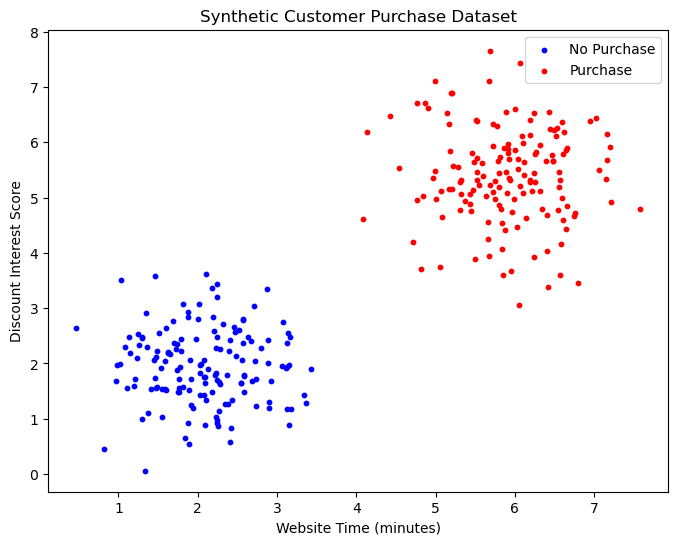

In [1]:
# Implementation using PyTorch
# Multi-Layer Artificial Neural Network Example
# Binary Classification: Customer Purchase Prediction

import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

# Seed for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Generate synthetic data for customers who did not purchase
num_samples = 150

non_buyer_time = np.random.normal(2.0, 0.6, num_samples)
non_buyer_discount_score = np.random.normal(2.0, 0.7, num_samples)
non_buyers = np.column_stack((non_buyer_time, non_buyer_discount_score))
labels_non_buyers = np.zeros(num_samples)

# Generate synthetic data for customers who purchased
buyer_time = np.random.normal(6.0, 0.7, num_samples)
buyer_discount_score = np.random.normal(5.5, 0.8, num_samples)
buyers = np.column_stack((buyer_time, buyer_discount_score))
labels_buyers = np.ones(num_samples)

# Combine both classes into one dataset
data = np.vstack((non_buyers, buyers)).astype(np.float32)
labels = np.hstack((labels_non_buyers, labels_buyers)).astype(np.float32).reshape(-1, 1)

# Shuffle the dataset
shuffle_index = np.random.permutation(len(data))
data = data[shuffle_index]
labels = labels[shuffle_index]

# Convert NumPy arrays to PyTorch tensors
x_train = torch.from_numpy(data)
y_train = torch.from_numpy(labels)

# Visualize the original dataset
plt.figure(figsize=(8, 6))

plt.scatter(
    non_buyer_time,
    non_buyer_discount_score,
    color="blue",
    s=10,
    label="No Purchase"
)

plt.scatter(
    buyer_time,
    buyer_discount_score,
    color="red",
    s=10,
    label="Purchase"
)

plt.xlabel("Website Time (minutes)")
plt.ylabel("Discount Interest Score")
plt.title("Synthetic Customer Purchase Dataset")
plt.legend()
plt.show()

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=4, bias=True)
  (5): ReLU()
  (6): Linear(in_features=4, out_features=1, bias=True)
  (7): Sigmoid()
)
Epoch 150/1500, Loss: 0.4998
Epoch 300/1500, Loss: 0.3921
Epoch 450/1500, Loss: 0.3025
Epoch 600/1500, Loss: 0.2315
Epoch 750/1500, Loss: 0.1832
Epoch 900/1500, Loss: 0.1507
Epoch 1050/1500, Loss: 0.1270
Epoch 1200/1500, Loss: 0.1096
Epoch 1350/1500, Loss: 0.0965
Epoch 1500/1500, Loss: 0.0863


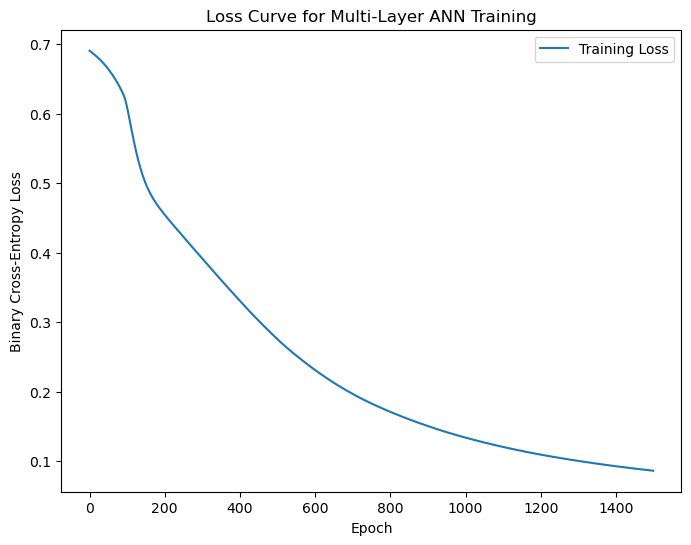

In [2]:

# Define a multi-layer artificial neural network
model = nn.Sequential(
    nn.Linear(2, 16),     # Input layer: 2 features -> 16 hidden neurons
    nn.ReLU(),            # Nonlinear activation

    nn.Linear(16, 8),     # Hidden layer 1: 16 neurons -> 8 neurons
    nn.ReLU(),            # Nonlinear activation

    nn.Linear(8, 4),      # Hidden layer 2: 8 neurons -> 4 neurons
    nn.ReLU(),            # Nonlinear activation

    nn.Linear(4, 1),      # Output layer: 4 neurons -> 1 output
    nn.Sigmoid()          # Sigmoid activation for binary classification
)

print(model)

# Define binary cross-entropy loss
criterion = nn.BCELoss()

# Define the SGD optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training settings
epochs = 1500
losses = []

# Training loop
for epoch in range(epochs):

    # Forward pass
    y_pred = model(x_train)

    # Compute binary classification loss
    loss = criterion(y_pred, y_train)
    losses.append(loss.item())

    # Backward pass and parameter update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 150 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot the training loss curve
plt.figure(figsize=(8, 6))
plt.plot(np.arange(epochs), np.array(losses, dtype=np.float32), label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Curve for Multi-Layer ANN Training")
plt.legend()
plt.show()


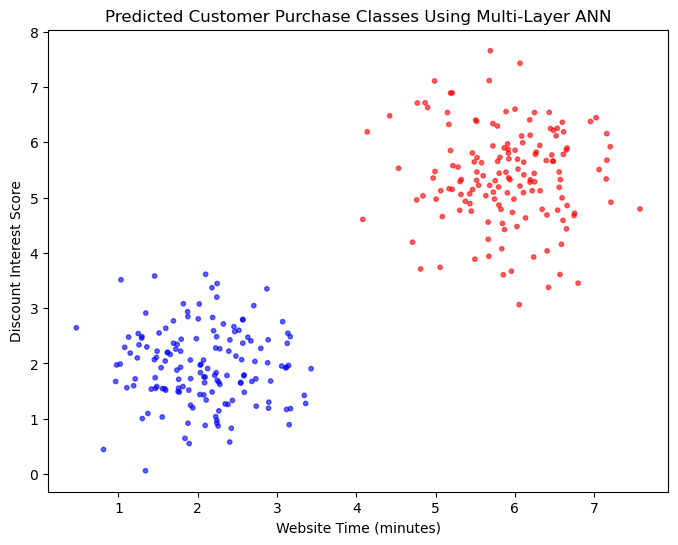

Final Accuracy: 100.00%


In [3]:

# Generate model predictions
with torch.no_grad():
    predictions = model(x_train)
    predicted_labels = (predictions >= 0.5).float()

# Visualize predicted classification results
plt.figure(figsize=(8, 6))
plt.scatter(
    data[:, 0],
    data[:, 1],
    c=predicted_labels.view(-1).numpy(),
    cmap="bwr",
    s=10,
    alpha=0.6
)

plt.xlabel("Website Time (minutes)")
plt.ylabel("Discount Interest Score")
plt.title("Predicted Customer Purchase Classes Using Multi-Layer ANN")
plt.show()

# Calculate final classification accuracy
accuracy = predicted_labels.eq(y_train).sum().item() / y_train.size(0)

print(f"Final Accuracy: {accuracy * 100:.2f}%")